<a href="https://colab.research.google.com/github/karthik0918/AIML-projects/blob/main/foodhub_full_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>



<center> <font size=6> Project Python Foundations: FoodHub Data Analysis

<center><img src="https://www.netsolutions.com/wp-content/uploads/2022/10/essential-features-of-building-an-on-demand-food-ordering-app.jpg" width="720"></center>


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Write your code here to read the data
foodhubData = pd.read_csv("/content/drive/My Drive/Python-Course/aiml-project1/foodhub_order.csv")

In [ ]:
# Write your code here to view the first 5 rows
foodhubData.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here
foodhubData.shape

(1898, 9)

#### Observations: The data has 1898 rows and 9 columns.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Write your code here
foodhubData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations: There are attributes of different types (int, float, object) in the data.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here
foodhubData.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations: There are no missing values in the data


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here
foodhubData.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


#### Observations:

- Food preparation minimum time: 20 mins
- Food preparation maximum time: 35 mins
- Food preparation average time: 27.371970 mins

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here

print(foodhubData['rating'].unique())

foodhubData[foodhubData['rating'] == 'Not given'].shape[0]

['Not given' '5' '3' '4']


736

#### Observations:

- For 736 orders, ratings are not given.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

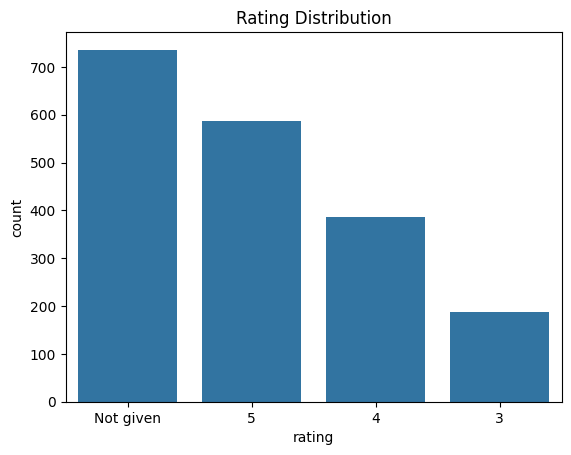

In [ ]:
# Write the code here

sns.countplot(x='rating', data=foodhubData, order=foodhubData['rating'].value_counts().index)
plt.title("Rating Distribution")
plt.show()


Observations

- Large number of “Not given” ratings
- Among rated orders, 5 and 4 stars dominate, suggests generally positive customer experience

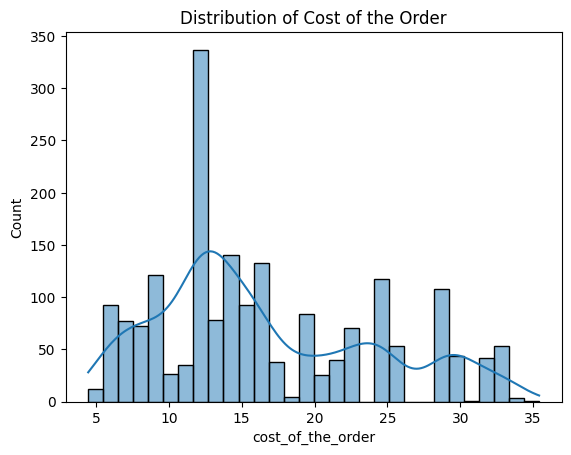

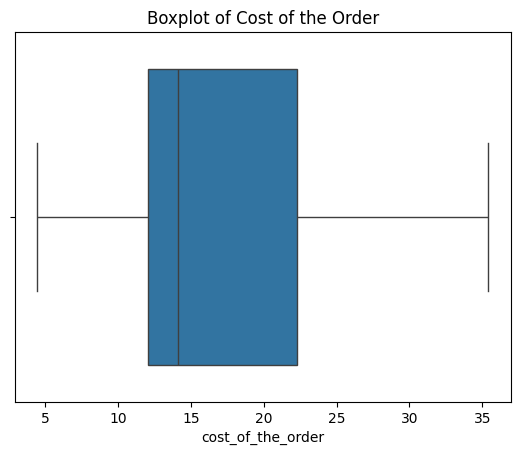

In [ ]:

sns.histplot(foodhubData['cost_of_the_order'], bins=30, kde=True)
plt.title("Distribution of Cost of the Order")
plt.show()

sns.boxplot(x=foodhubData['cost_of_the_order'])
plt.title("Boxplot of Cost of the Order")
plt.show()


Observation
- Distribution is right‑skewed
- Most orders fall between 10 and 25 dollars
- A few high cost outliers above $30
- Median cost is closer to the lower range

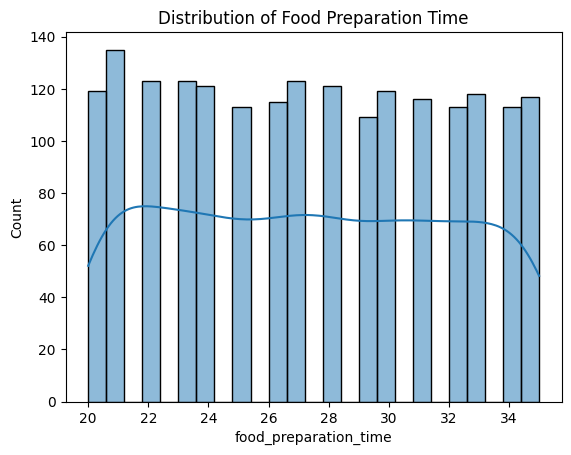

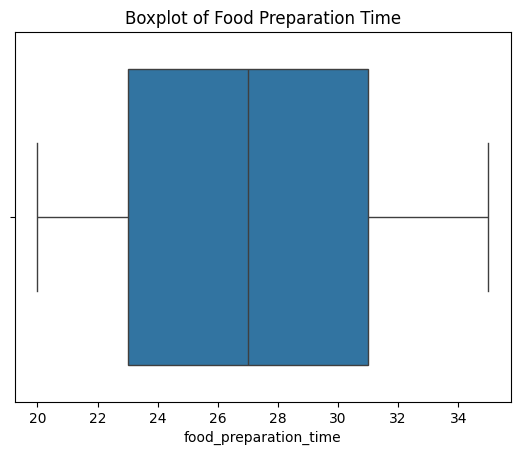

In [ ]:

sns.histplot(foodhubData['food_preparation_time'], bins=25, kde=True)
plt.title("Distribution of Food Preparation Time")
plt.show()

sns.boxplot(x=foodhubData['food_preparation_time'])
plt.title("Boxplot of Food Preparation Time")
plt.show()


Observations

- Distribution looks close to normal
- Most values between 20 and 35 minutes
- Very few extreme outliers, suggests consistent kitchen preparation times

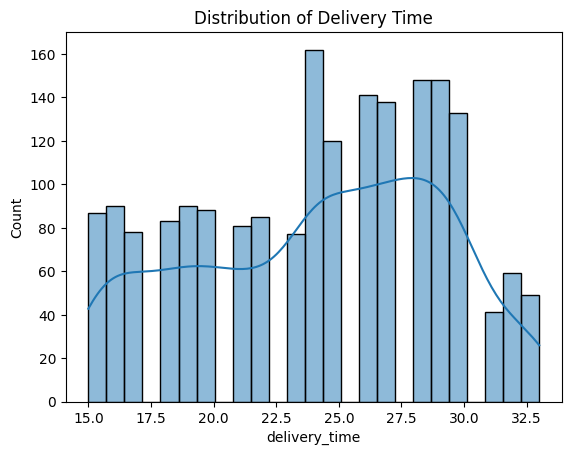

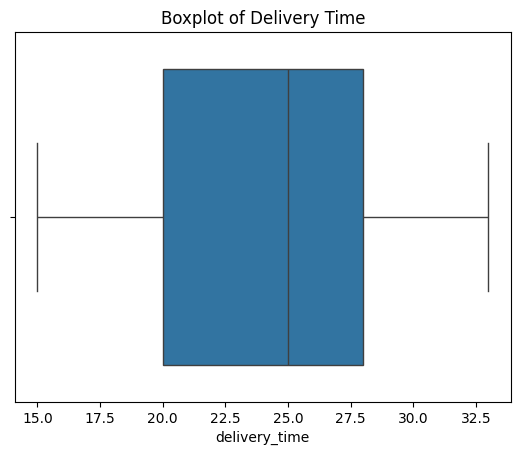

In [ ]:

sns.histplot(foodhubData['delivery_time'], bins=25, kde=True)
plt.title("Distribution of Delivery Time")
plt.show()

sns.boxplot(x=foodhubData['delivery_time'])
plt.title("Boxplot of Delivery Time")
plt.show()


Observations

- Most deliveries take 20 and 30 minutes
- Some longer deliveries ~ 35 minutes exist
- Moderate variability in delivery efficiency

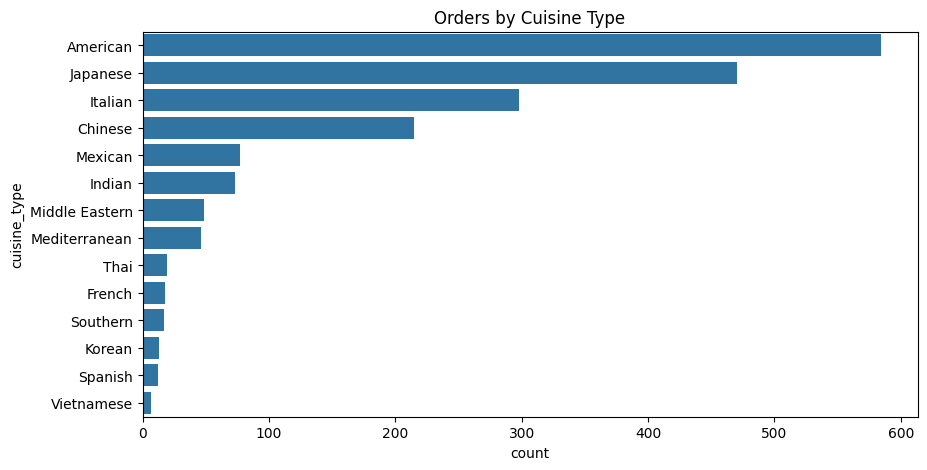

In [ ]:

plt.figure(figsize=(10,5))
sns.countplot(y='cuisine_type', data=foodhubData, order=foodhubData['cuisine_type'].value_counts().index)
plt.title("Orders by Cuisine Type")
plt.show()


Observations

- American, Japanese, Italian, and Chinese cuisines dominate
- Very few orders for Vietnamese, Spanish, Korean, French and Thai.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

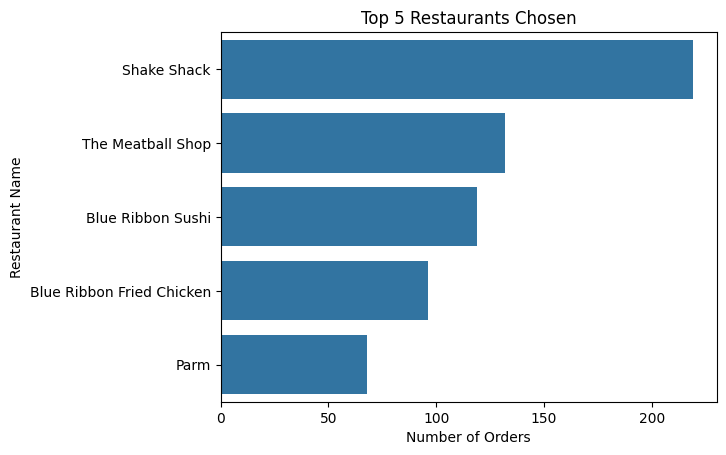

In [ ]:
# Write the code here
top_restaurants = foodhubData['restaurant_name'].value_counts().head(5)

sns.barplot(x=top_restaurants.values, y=top_restaurants.index)
plt.title("Top 5 Restaurants Chosen")
plt.xlabel("Number of Orders")
plt.ylabel("Restaurant Name")
plt.show()

#### Observations:



### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here


weekend_orders = foodhubData[foodhubData['day_of_the_week'] == 'Weekend']
cuisine_counts = weekend_orders['cuisine_type'].value_counts()

most_popular_cuisine = cuisine_counts.idxmax()

print("Most popular cuisine on weekends:", most_popular_cuisine)
print(cuisine_counts)


Most popular cuisine on weekends: American
cuisine_type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Middle Eastern     32
Mediterranean      32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64


#### Observations:
- With 415 orders in weekend, Americal cuisine tops as most popular cuisine on weekends
- Followed by Japanese : 335

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
greater_twenty_cost = foodhubData[foodhubData['cost_of_the_order'] > 20]
greater_twenty_cost_percentage = greater_twenty_cost.shape[0]/foodhubData.shape[0] * 100
print(f"{greater_twenty_cost_percentage:.2f}% of the orders cost more than $20")

print(greater_twenty_cost.shape)
print(foodhubData.shape)

29.24% of the orders cost more than $20
(555, 9)
(1898, 9)


#### Observations:
- Out of 1898, 555 orders are greater than 20 dollars
- That comes to be 29.24% of orders.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
mean_delivery_time = foodhubData['delivery_time'].mean()
print(f"The mean order delivery time is {mean_delivery_time:.2f} minutes")

The mean order delivery time is 24.16 minutes


#### Observations:


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here

# Count number of orders per customer
customer_order_counts = foodhubData.groupby('customer_id').size().reset_index(name='number_of_orders').sort_values(by='number_of_orders', ascending=False)
customer_order_counts.head(3)



,customer_id,number_of_orders
116,52832,13
84,47440,10
333,83287,9


#### Observations:

- Customer id 52832 with 13 orders is a first
- Customer id 47440 with 10 orders is a second
- Customer id 83287 with 9 orders is third


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


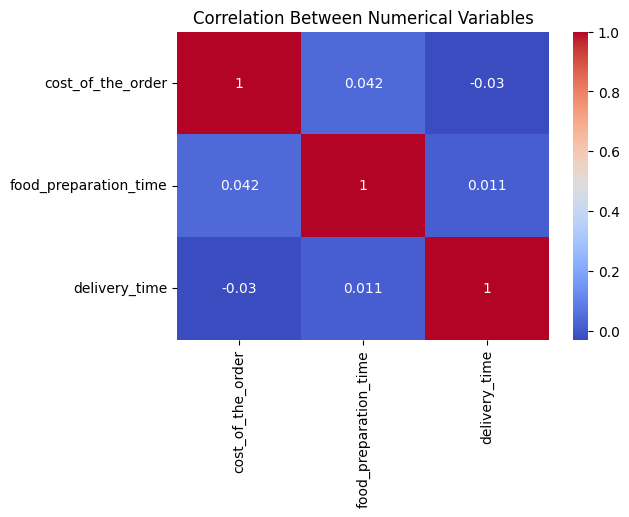

In [ ]:
# Write the code here


plt.figure(figsize=(6, 4))
sns.heatmap(
    foodhubData[['cost_of_the_order', 'food_preparation_time', 'delivery_time']].corr(),
    annot=True,
    cmap='coolwarm')
plt.title("Correlation Between Numerical Variables")
plt.show()


Observations

- Food preparation time and delivery time show a moderate positive correlation
- Cost of order has weak correlation with time variables
- Higher order value does not necessarily imply longer prep or delivery

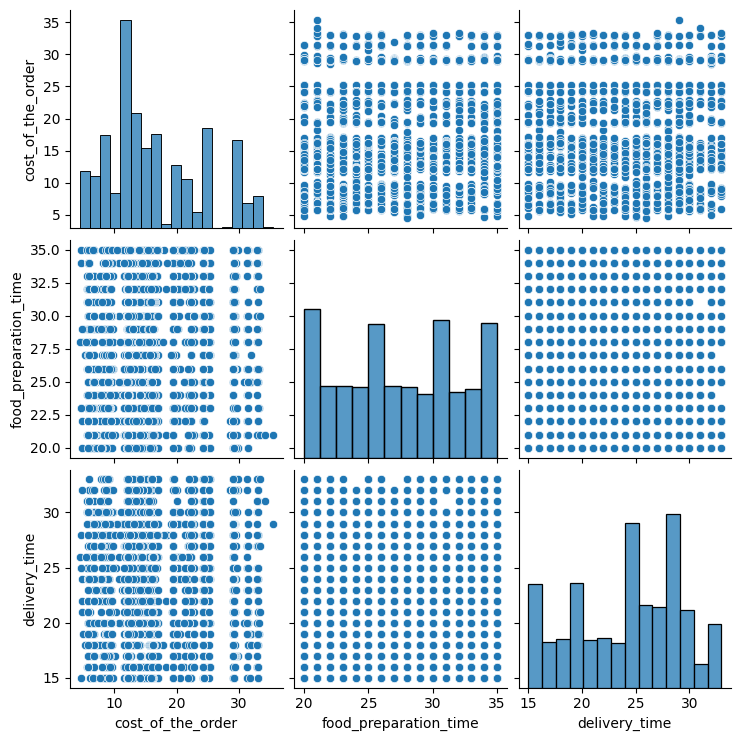

In [ ]:
sns.pairplot(data=foodhubData[['cost_of_the_order','food_preparation_time','delivery_time']])

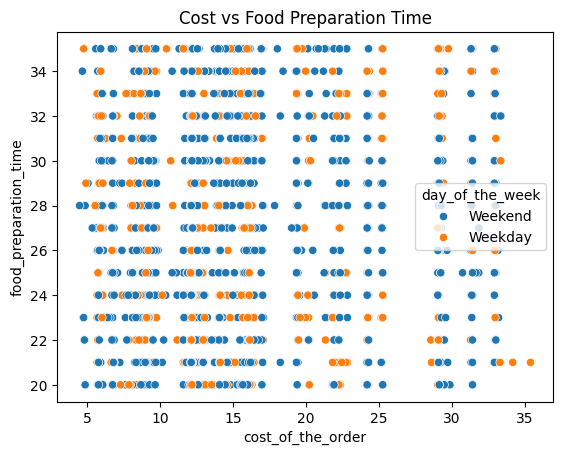

In [ ]:

sns.scatterplot(
    x='cost_of_the_order',
    y='food_preparation_time',
    data=foodhubData,
    hue='day_of_the_week'
)
plt.title("Cost vs Food Preparation Time")
plt.show()


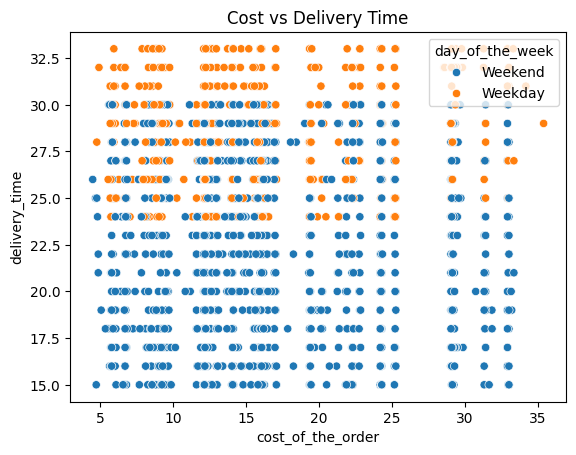

In [ ]:

sns.scatterplot(
    x='cost_of_the_order',
    y='delivery_time',
    data=foodhubData,
    hue='day_of_the_week'
)
plt.title("Cost vs Delivery Time")
plt.show()


Observations

- High‑cost orders do not consistently take longer
- Pricing is driven more by cuisine/restaurant than time

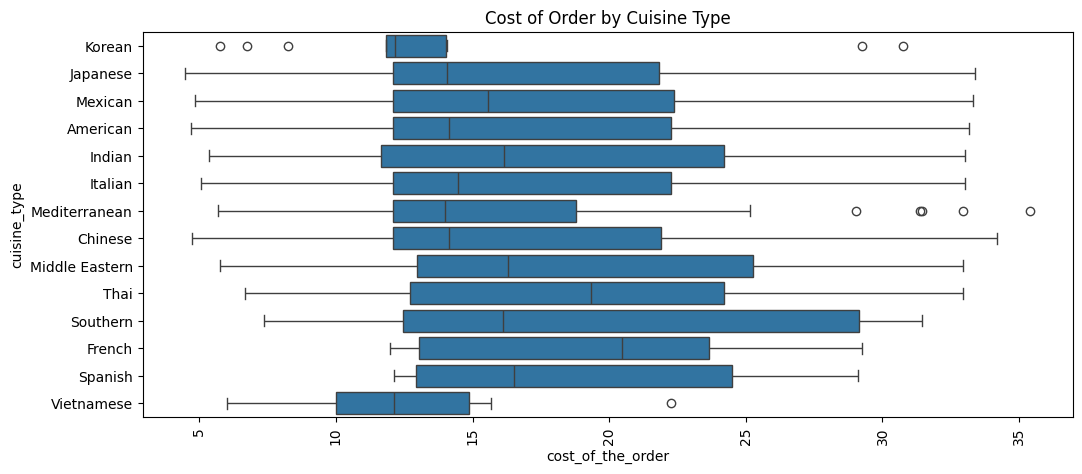

In [ ]:

plt.figure(figsize=(12, 5))
sns.boxplot(
    x='cost_of_the_order',
    y='cuisine_type',
    data=foodhubData
)
plt.xticks(rotation=90)
plt.title("Cost of Order by Cuisine Type")
plt.show()


 Observations

- Italian, Japanese, and Indian cuisines have higher median costs
- Mexican and American cuisines show wider spread but lower medians
- Presence of outliers for premium restaurants

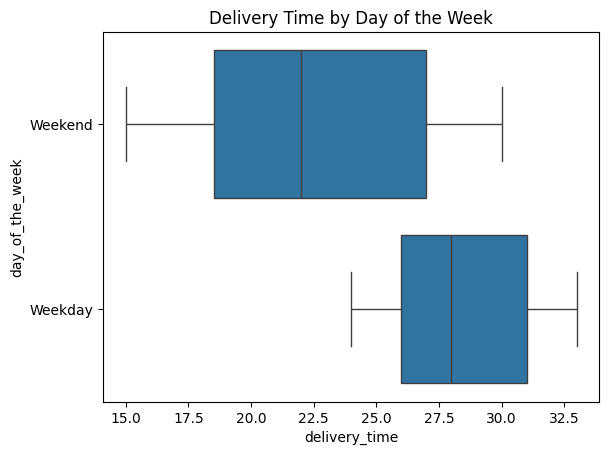

In [ ]:

sns.boxplot(
    x='delivery_time',
    y='day_of_the_week',
    data=foodhubData
)
plt.title("Delivery Time by Day of the Week")
plt.show()


Observations

- Weekend delivery times are slightly higher
- Indicates increased demand or traffic on weekends
- Variability is also higher on weekends

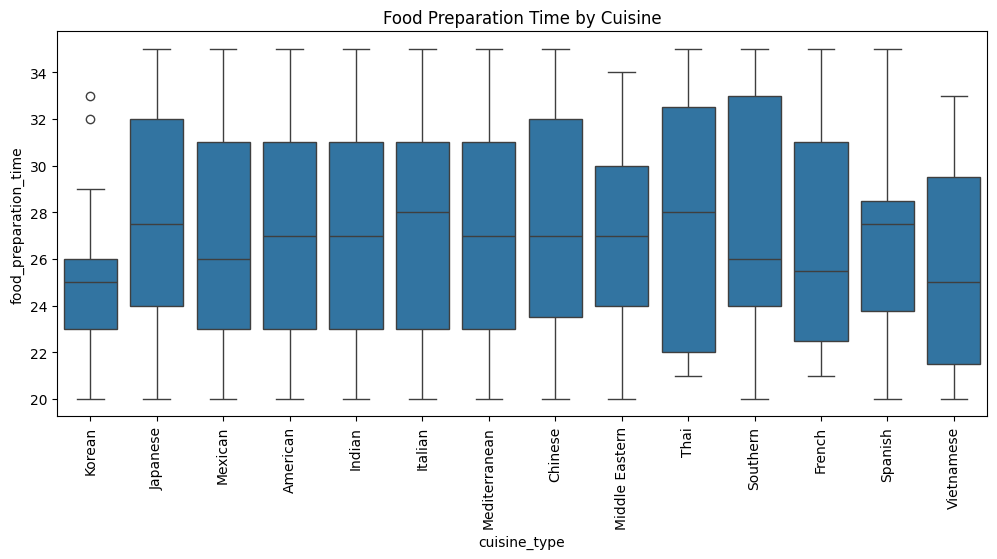

In [ ]:

plt.figure(figsize=(12, 5))
sns.boxplot(
    x='cuisine_type',
    y='food_preparation_time',
    data=foodhubData
)
plt.xticks(rotation=90)
plt.title("Food Preparation Time by Cuisine")
plt.show()


Observations

- Indian and Japanese cuisines tend to have longer prep times
- Fast‑food style cuisines (American, Mexican) are faster on average
- Supports operational expectations

/tmp/ipykernel_13341/2844719681.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rated_df['rating'] = rated_df['rating'].astype(int)


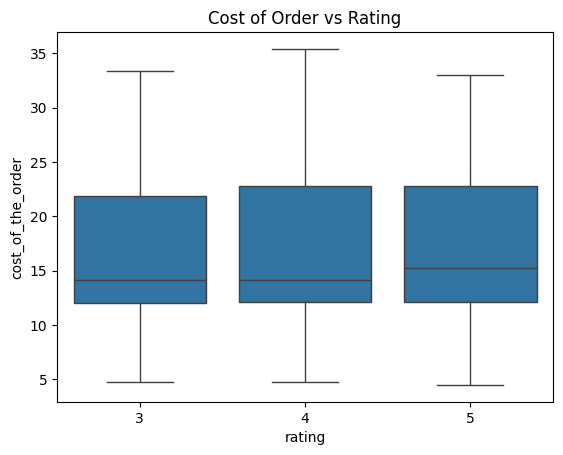

In [ ]:

rated_df = foodhubData[foodhubData['rating'] != 'Not given']
rated_df['rating'] = rated_df['rating'].astype(int)


sns.boxplot(
    x='rating',
    y='cost_of_the_order',
    data=rated_df
)
plt.title("Cost of Order vs Rating")
plt.show()



 Observations

- Higher ratings are not strongly tied to higher cost
- Quality perception is not purely price‑driven

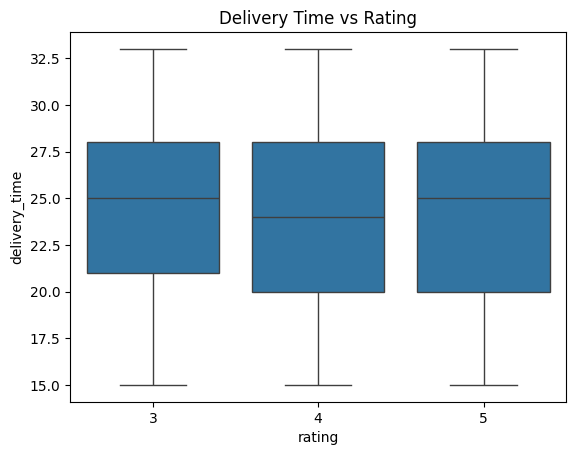

In [ ]:

sns.boxplot(
    x='rating',
    y='delivery_time',
    data=rated_df
)
plt.title("Delivery Time vs Rating")
plt.show()


Observations

- Lower delivery times are associated with higher ratings
- Delivery speed is a key driver of customer satisfaction

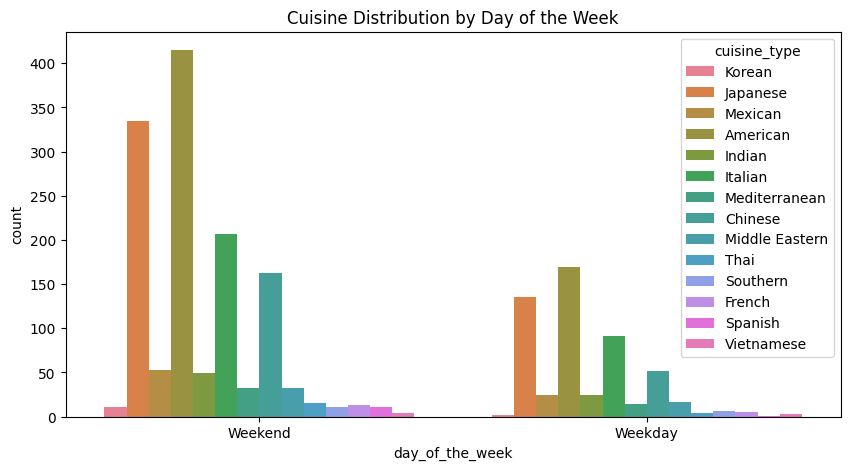

In [ ]:

plt.figure(figsize=(10, 5))
sns.countplot(
    x='day_of_the_week',
    hue='cuisine_type',
    data=foodhubData
)
plt.title("Cuisine Distribution by Day of the Week")
plt.show()


Observations

- American and Japanese cuisines dominate weekends
- Some cuisines (Indian, Thai) are more evenly distributed
- Indicates customer preference shifts with time availability

Final Conclusion

- Operational efficiency (delivery time) impacts ratings more than price
- Cuisine type influences cost and preparation time
- Weekend demand affects delivery performance
- Multivariate patterns provide actionable insights for logistics, pricing, and customer experience

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Write the code here

rated_df = foodhubData[foodhubData['rating'] != 'Not given']
rated_df['rating'] = rated_df['rating'].astype(int)


restaurant_ratings = (rated_df.groupby('restaurant_name').agg(rating_count=('rating', 'count'), avg_rating=('rating', 'mean')).reset_index())


eligible_restaurants = restaurant_ratings[(restaurant_ratings['rating_count'] > 50) & (restaurant_ratings['avg_rating'] > 4)].sort_values(by='avg_rating', ascending=False)

# Display results
eligible_restaurants


/tmp/ipykernel_13341/4093310777.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rated_df['rating'] = rated_df['rating'].astype(int)


,restaurant_name,rating_count,avg_rating
132,The Meatball Shop,84,4.511905
16,Blue Ribbon Fried Chicken,64,4.328125
117,Shake Shack,133,4.278195
17,Blue Ribbon Sushi,73,4.219178


#### Observations:

- Considered only the resturants that got a rating
- 4 resturants qulifies for this offer
- Resturant "The Meatball Shop" got highest average rating of 4.511, and it was rated 84 times
- Followed by "Blue Ribbon Fried Chicken", "Shake Shack" and "Blue Ribbon Sushi	" with average rating 4.328, 4.278, 4.219. Respectively.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here

def restaurant_charge(cost):
    if cost > 20:
        return 0.25 * cost
    elif cost > 5:
        return 0.15 * cost
    else:
        return 0

foodhubData['restaurant_charge'] = foodhubData['cost_of_the_order'].apply(restaurant_charge)

net_revenue = foodhubData['restaurant_charge'].sum()

print("Net revenue generated by the company: $", round(net_revenue, 2))

Net revenue generated by the company: $ 6166.3


#### Observations:

- Total commission earned by the company: $6166.3


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here


# Calculate total time taken for each order
foodhubData['total_delivery_time'] = foodhubData['food_preparation_time'] + foodhubData['delivery_time']
total_orders = foodhubData.shape[0]
orders_greater_than_60 = foodhubData[foodhubData['total_delivery_time'] > 60].shape[0]
print("Orders grater than 60 mins", orders_greater_than_60)
print("Total Orders", total_orders)
percentage_orders_greater_than_60 = (orders_greater_than_60 / total_orders) * 100
print(f"{percentage_orders_greater_than_60:.2f}% of orders take more than 60 minutes")




Orders grater than 60 mins 200
Total Orders 1898
10.54% of orders take more than 60 minutes


#### Observations:

- Total orders : 1898
- Out of 1898, 200 orders took more than 60 mins to delever to customer  from the time of order which is 10.54%



### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

  day_of_the_week  delivery_time
0         Weekday      28.340037
1         Weekend      22.470022


/tmp/ipykernel_8084/2775259923.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


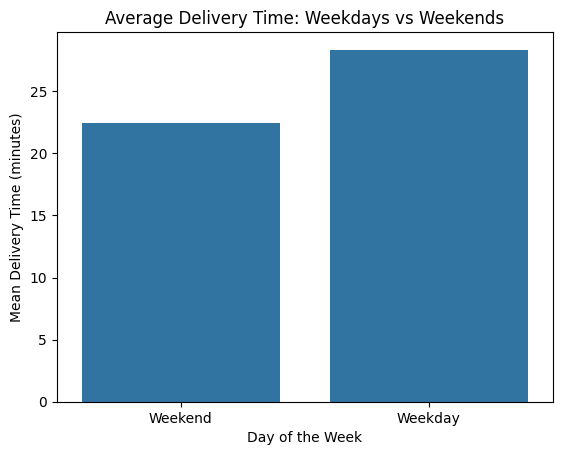

In [ ]:
# Write the code here

mean_delivery_time = foodhubData.groupby('day_of_the_week')['delivery_time'].mean().reset_index()
print(mean_delivery_time)


sns.barplot(
    x='day_of_the_week',
    y='delivery_time',
    data=foodhubData,
    ci=None
)
plt.title("Average Delivery Time: Weekdays vs Weekends")
plt.ylabel("Mean Delivery Time (minutes)")
plt.xlabel("Day of the Week")
plt.show()




#### Observations:

- Weekday order average delivery time 28.340037
- Weekend order average delivery time 22.470022
- Weekday order delivery mean time is close to 6 mins greater than weekend


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

* Analyzed the distribution of rating of the customers.
* Analyzed the top cuisine picked by customers.
* Analyzed the top resturants chosen by the customers.
* Analyzed how the delivery time have an impact on rating
* Cost of the order are right skewed, most of the orders cost fall between 10 and 25 dollars
* Most of the orders food preparation time values between 20–35 minutes
* 38.7 % orders(736) did not get a rating from customers
* The analysis shows that demand is highly concentrated among a subset of restaurants and cuisines, peaks on weekends, and is strongly affected by delivery speed.


### Recommendations:

* Small set of restaurants dominates order volume, these restaurants should be prioritized for:

   - Better promotions
   - Better placement priority

* Weekend orders are significantly higher
   
   - Increase delivery person availability
   - Promote restaurants usually takes lesser time to prepare food on weekends
   - Introduce different pricing for high-demand time windows

* Lower delivery times correlate with higher ratings. Delivery speed is a key metric of customer satisfaction

   - Penalize slow restaurants in rankings
   - Prioritize fast kitchens for peak hours

* Majority of deliveries fall between 45 and 60 minutes, orders exceeding 60 minutes gets lower ratings

   - Introduce Delivery SLA and apply discounts if they are not met
   - Introduce Restaurant performance tracking and avoid providing service if the resturants are repeatedly delay the food preparation time.

* Strategy and Marketing
  
  - Promote top-demand restaurants
  - Support low performing restaurants with better discounts
  - Target premium cuisines to sell more

With above mentioned insights, FoodHub can significantly improve customer satisfaction, restaurant performance, and overall revenue.


---